# `qEA_vary_T.ipynb`: Edwards-Anderson overlap $q_{EA}$ by temperature

In [1]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from scipy.stats import sem

from utils.modelIO import *
from utils.overlaps import *

In [2]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
BIO_SIM_PATH = Path('results/eml/bio_vary_T/')
RAND_SIM_PATH = Path('results/eml/rand_vary_T/')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
temperatures = jnp.linspace(0.0, 1.0, 21)

bio_fns = [BIO_SIM_PATH.joinpath('bio_T_{:.0e}_xs.npy'.format(T)) for T in temperatures]
rand_fns = [RAND_SIM_PATH.joinpath('rand_T_{:.0e}_xs.npy'.format(T)) for T in temperatures]

Compute average $q_{AE}$ for all trajectories in each file

In [3]:
# vmap over trajectories
def get_qAE_instance(grn_states):
    return get_qAE(grn_states, N, N**2)
get_qAE_vmap = jax.vmap(get_qAE_instance)

# load file and compute qAE mean and standard error
def get_avg_qAE(filename):
    xs = jnp.load(filename)
    qAEs = get_qAE_vmap(xs)
    return jnp.mean(qAEs), sem(qAEs)

In [4]:
bio_qAEs = jnp.array([get_avg_qAE(bio_fn) for bio_fn in bio_fns])
rand_qAEs = jnp.array([get_avg_qAE(rand_fn) for rand_fn in rand_fns])

Plot $q_{AE}$

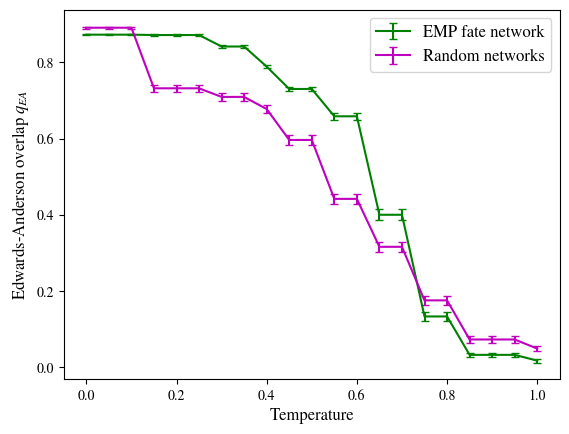

In [5]:
fig, ax = plt.subplots()
ax.errorbar(temperatures, bio_qAEs[:, 0],
            yerr=bio_qAEs[:, 1], capsize=3.0, c='g', label='EMP fate network')
ax.errorbar(temperatures, rand_qAEs[:, 0],
            yerr=rand_qAEs[:, 1], capsize=3.0, c='m', label='Random networks')
ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel('Edwards-Anderson overlap $q_{EA}$', fontsize=12)
ax.legend(fontsize=12)
plt.savefig(FIG_SAVE_PATH.joinpath('qEA_vary_T.pdf'), bbox_inches='tight')